In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report)
from sklearn.metrics import (confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier 

In [55]:
#UNDERSTAND DATASET
df =pd.read_csv(r"C:\Users\Priya\OneDrive\Desktop\SHUBHAM\Data Science Projects\URBAN  COMPANY SERVICE INTELLIGENCE & CHURN RISK ANALYSIS\data\uc.csv")
df.head() # see the data how its look like 
df.shape # Check the size of the dataset
df.info() #Let take the complete structure of dataset
df.describe # Lets generate a statistical summary of dataset
df.isnull().sum() # Lets findout missing values exist in each column.
df['service'].unique()  # Its shows all distinct services available
# inservice i found two different name with same meaning like :- ac_service_repair Or ac_service_repairs
# So replace ac_service_repair and make one <String Array>
df['service']= df['service'].replace(
    'ac_service_repairs', 
    'ac_service_repair')
df['service'].unique() # This is for check in the column name is service & find all the service as a <String Array>
df['service'].value_counts() # counts all services i want to know which service is most common and least common service or Business demand distribution.


<class 'pandas.DataFrame'>
RangeIndex: 8530 entries, 0 to 8529
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   service            8530 non-null   str  
 1   subservice_name    8530 non-null   str  
 2   subservice_charge  8530 non-null   str  
 3   city_name          8530 non-null   str  
 4   country_name       8530 non-null   str  
 5   source             8530 non-null   str  
dtypes: str(6)
memory usage: 400.0 KB


service
ac_service_repair    2623
electricians         2209
plumbers             2193
microwave_repair     1505
Name: count, dtype: int64

In [56]:
# see In the above subservice_charge D type shows a string but we required a numerical value so 
# the GOAL is => str to 'int' ok 
df['subservice_charge'] = (df['subservice_charge']
   .astype(str)                        
  .str.replace('₹', '', regex=False)
  .str.replace('[', '', regex=False)
  .str.replace(']', '', regex=False)
  .str.replace("'", '', regex=False)
  .str.strip())

# CONVERT TO NUMBER
df['subservice_charge'] = pd.to_numeric(
    df['subservice_charge'],
    errors='coerce')

df.info()
df['subservice_charge'].isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 8530 entries, 0 to 8529
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   service            8530 non-null   str    
 1   subservice_name    8530 non-null   str    
 2   subservice_charge  6166 non-null   float64
 3   city_name          8530 non-null   str    
 4   country_name       8530 non-null   str    
 5   source             8530 non-null   str    
dtypes: float64(1), str(5)
memory usage: 400.0 KB


np.int64(2364)

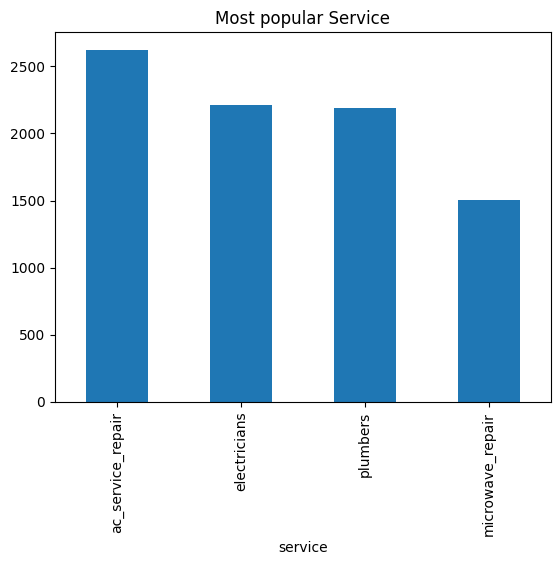

In [57]:
# BASIC EDA 
# FIND OUT MOST POPULAR CITIES IN THE FORM OF VISUALIZATION
df['service'].value_counts().plot(kind='bar')
plt.title("Most popular Service")
plt.show()


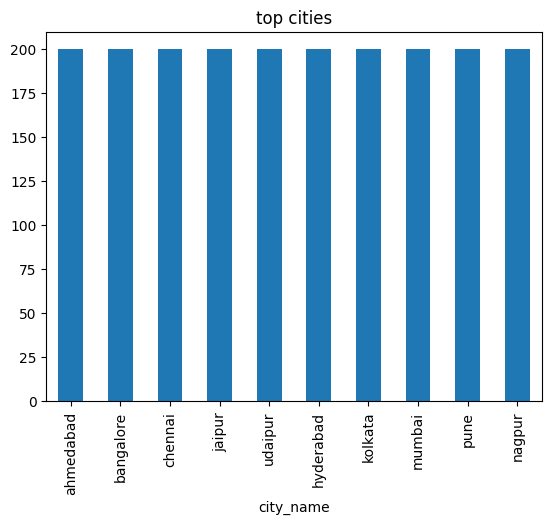

In [58]:
# Figure Out Top 10 cities where services used the most.
df['city_name'].value_counts().head(10).plot(kind='bar')
plt.title("top cities")
plt.show()

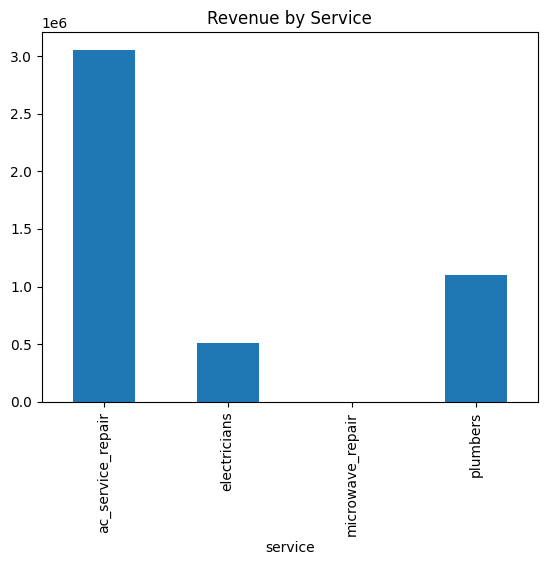

In [59]:
# Revenue by service
df.groupby('service')['subservice_charge'].sum()
# This calculates : Total revenue generated by each service.

#VISUALIZATION
df.groupby('service')['subservice_charge'].sum().plot(kind='bar')
plt.title("Revenue by Service")
plt.show()

In [60]:

# DATA ENRICHMENT
# Where project transforms into : 
# * Customer Analysis
# * Behavioural Model
# * Churn Prediction Model


# So First is Add Customers 
np.random.seed(42)
df['customer_id'] = np.random.randint(1000, 5000, size=len(df))
df.info()
df.head()

# Second is Add Booking Date
df['booking_date'] = pd.to_datetime(np.random.choice(
    pd.date_range('2025-04-01','2026-03-31'),
    size=len(df)))
df.info()
df.head()


# Third is Add Customer Rating
df['customer_rating'] = np.round(np.random.uniform(2.5,5.0,
    size=len(df)),1)
df.info()
df.head()
# Fourth is Add CANCELLATION FLAG
df['cancelled'] = np.random.choice(
  ['yes','No'],
  p=[0.15, 0.85],
  size=len(df))
df.head()
# Fifth is Add Membership Flag
df['membership_flag'] = np.random.choice(
    ['Gold','Silver','None'],
    p=[0.2,0.3,0.5],
    size=len(df))
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 8530 entries, 0 to 8529
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   service            8530 non-null   str    
 1   subservice_name    8530 non-null   str    
 2   subservice_charge  6166 non-null   float64
 3   city_name          8530 non-null   str    
 4   country_name       8530 non-null   str    
 5   source             8530 non-null   str    
 6   customer_id        8530 non-null   int32  
dtypes: float64(1), int32(1), str(5)
memory usage: 433.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 8530 entries, 0 to 8529
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   service            8530 non-null   str           
 1   subservice_name    8530 non-null   str           
 2   subservice_charge  6166 non-null   float64       
 3   city_name          8530 non-null   str

,service,subservice_name,subservice_charge,city_name,country_name,source,customer_id,booking_date,customer_rating,cancelled,membership_flag
0,ac_service_repair,Non-Inverter PCB repaired,1800.0,ahmedabad,India,UrbanCompany,4174,2026-03-05,2.9,No,None
1,ac_service_repair,Inverter PCB repaired,4000.0,ahmedabad,India,UrbanCompany,4507,2025-12-22,3.1,yes,None
2,ac_service_repair,Replace LVT,NaN,ahmedabad,India,UrbanCompany,1860,2026-03-14,4.3,No,None
3,ac_service_repair,Capacitor 2-5 mfd,NaN,ahmedabad,India,UrbanCompany,2294,2025-04-29,4.5,No,None
4,ac_service_repair,Capacitor 10-25 mfd,NaN,ahmedabad,India,UrbanCompany,2130,2025-05-05,3.2,No,None


In [61]:
# Customer Analytics Table
# Create Customer-level behaviour

# Aggregate Customer Data
customer_df = df.groupby('customer_id').agg({
    'subservice_charge': ['sum', 'mean', 'count'],
    'customer_rating': 'mean',
    'cancelled': lambda x: (x == 'Yes').sum()
})


# CLEAN & FLATTEN COLUMN NAMES 
# Rename messy column names into clean readable names
customer_df.columns = [
    'total_spend',
    'avg_spend',
    'total_bookings',
    'avg_rating',
    'total_cancellation'
]
customer_df = customer_df.reset_index()
customer_df.head()


,customer_id,total_spend,avg_spend,total_bookings,avg_rating,total_cancellation
0,1000,507.0,507.0,1,4.600,0
1,1001,957.0,319.0,3,3.975,0
2,1002,1034.0,517.0,2,3.950,0
3,1003,319.0,319.0,1,2.700,0
4,1004,169.0,169.0,1,3.100,0


In [62]:
# Create Recency Feature
# Days since customer's last booking

latest_date = df['booking_date'].max()

recency_df = df.groupby('customer_id')['booking_date'].max().reset_index()

recency_df['recency_days'] = (
    latest_date - recency_df['booking_date']
).dt.days

recency_df.head()

# Merge 
customer_df = customer_df.merge(
    recency_df[['customer_id', 'recency_days']],
    on='customer_id',
    how='left')

customer_df.head()
# Reset Index



,customer_id,total_spend,avg_spend,total_bookings,avg_rating,total_cancellation,recency_days
0,1000,507.0,507.0,1,4.600,0,244
1,1001,957.0,319.0,3,3.975,0,42
2,1002,1034.0,517.0,2,3.950,0,339
3,1003,319.0,319.0,1,2.700,0,355
4,1004,169.0,169.0,1,3.100,0,167


In [63]:
# Business Logic 
# If customer inactive for more than  >90 days inactive 1   
# customer probably left platform
customer_df['churn'] = np.where(
    customer_df['recency_days'] > 90,1,0)

customer_df.head()

,customer_id,total_spend,avg_spend,total_bookings,avg_rating,total_cancellation,recency_days,churn
0,1000,507.0,507.0,1,4.600,0,244,1
1,1001,957.0,319.0,3,3.975,0,42,0
2,1002,1034.0,517.0,2,3.950,0,339,1
3,1003,319.0,319.0,1,2.700,0,355,1
4,1004,169.0,169.0,1,3.100,0,167,1


In [64]:
# FEATURE & TARGET SEPARATION
# Main Object
# Prepare dataset for : 
# x means Input data/features These are customer behaviour ML Studies 
# Y means answer/output This is what ML Predicts : Churn or not churn 
X = customer_df[
    [ 'total_spend',
        'avg_spend',
        'total_bookings',
        'avg_rating',
        'total_cancellation',
        'recency_days']]

y = customer_df['churn']
X.head()
y.head()

0    1
1    0
2    1
3    1
4    1
Name: churn, dtype: int64

In [65]:

X = X.fillna(0) # This is a missing value handling 
# Train Test Split  "X features" & "Y Target"
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape) 


(2809, 6)
(703, 6)


In [66]:
# Train First ML Model 
model = LogisticRegression()
model.fit(X_train, y_train)

c:\Users\Priya\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [67]:
# Prediction
y_pred = model.predict(X_test)
print(y_pred[:10])

[0 0 1 1 1 1 1 1 1 0]


Model Accuracy: 0.9957325746799431
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       313
           1       0.99      1.00      1.00       390

    accuracy                           1.00       703
   macro avg       1.00      1.00      1.00       703
weighted avg       1.00      1.00      1.00       703

[[310   3]
 [  0 390]]


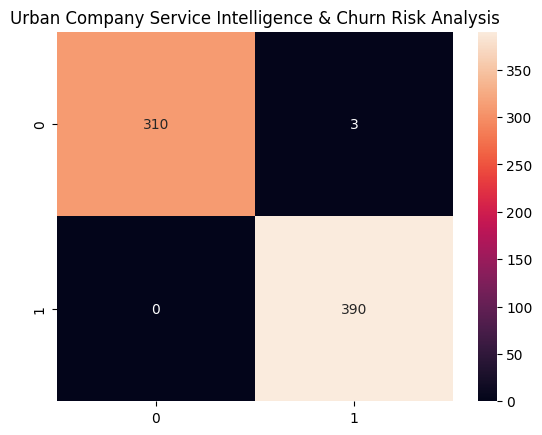

In [68]:
# EVALUATION
# Accuracy
accuracy = accuracy_score(y_test, y_pred)   # Accuracy = Correct Predictions/Total Predictions
print("Model Accuracy:", accuracy)

# Confusion Matrix
#This Helps understand : 
  # * Correct predictions
  # * Wrong predictions
  # * Churn detection quality

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion_matrix 
cm = confusion_matrix(y_test, y_pred)

print(cm)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Urban Company Service Intelligence & Churn Risk Analysis")

plt.show()








In [69]:
# Feature Importance with Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})

feature_importance = feature_importances.sort_values(
    by='importance',
    ascending=False
)
print(feature_importance)

              feature  importance
5        recency_days    0.945498
2      total_bookings    0.017814
0         total_spend    0.015477
1           avg_spend    0.011520
3          avg_rating    0.009692
4  total_cancellation    0.000000


In [70]:
# Model Improvement + Business Intelligence
# I Built a business-ready churn intelligence system
# This next phase is where your Data Science project becomes a real-world solution.
# Train Advance model 
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)




,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [71]:
# RANDOM FOREST PREDICTIONS
rf_pred = rf_model.predict(X_test)

In [72]:
# EVALUATE RANDOM FOREST 
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


In [73]:
# Random Forest Classification Report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       313
           1       1.00      1.00      1.00       390

    accuracy                           1.00       703
   macro avg       1.00      1.00      1.00       703
weighted avg       1.00      1.00      1.00       703



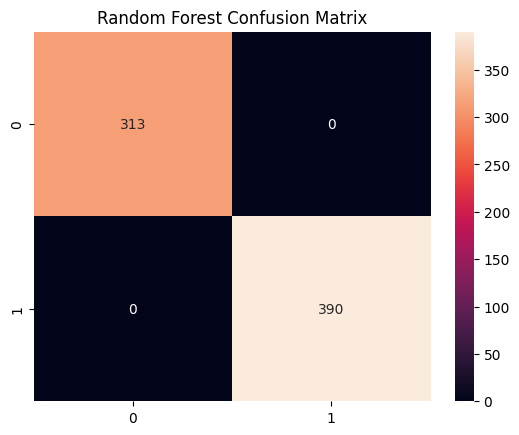

In [74]:
# Random Forest Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(rf_cm, annot=True, fmt='d')

plt.title("Random Forest Confusion Matrix")
plt.show()

In [75]:
# FEATURE IMPORTANCE (VERY IMPORTANT)
# This Tells : Why customers churn.
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='importance',
    ascending=False
)

print(importance)

              feature  importance
5        recency_days    0.945498
2      total_bookings    0.017814
0         total_spend    0.015477
1           avg_spend    0.011520
3          avg_rating    0.009692
4  total_cancellation    0.000000


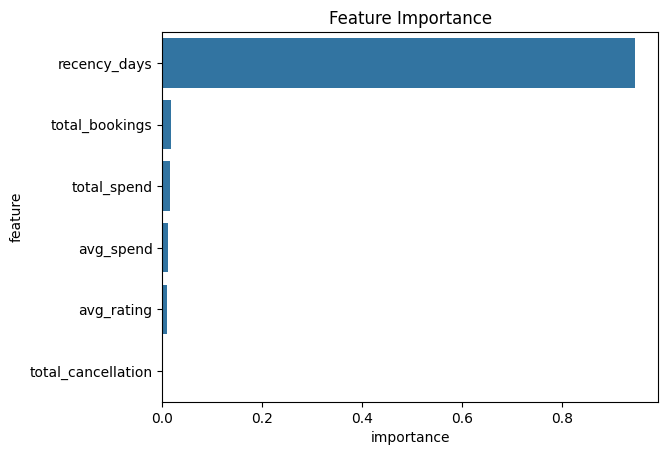

In [76]:
# VISUALIZE FEATURE IMPORTANCE 
sns.barplot(
    x='importance',
    y='feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

In [77]:
# CREATE CHURN RISK SEGMENTS 
customer_df['churn_probability'] = rf_model.predict_proba(X)[:, 1]

# Create Risk Categories 
def risk_category(prob):
    
    if prob >= 0.75:
        return 'High Risk'
    
    elif prob >= 0.40:
        return 'Medium Risk'
    
    else:
        return 'Low Risk'
# Create Risk Category Column
    customer_df['risk_category'] = customer_df['churn_probability'].apply(risk_category)
customer_df.head()

,customer_id,total_spend,avg_spend,total_bookings,avg_rating,total_cancellation,recency_days,churn,churn_probability
0,1000,507.0,507.0,1,4.600,0,244,1,1.0
1,1001,957.0,319.0,3,3.975,0,42,0,0.0
2,1002,1034.0,517.0,2,3.950,0,339,1,1.0
3,1003,319.0,319.0,1,2.700,0,355,1,1.0
4,1004,169.0,169.0,1,3.100,0,167,1,1.0


In [78]:
# Create Recommendations
def retention_action(segment):
    
    if segment == 'High Risk':
        return 'Give Discount Offer'
    
    elif segment == 'Medium Risk':
        return 'Send Reminder Notification'
    
    else:
        return 'Loyal Customer Benefits'
    
# Apply Recommendation Logic
    customer_df['retention_action'] = customer_df[
    'risk_segment'
    ].apply(retention_action)

In [79]:
# EXPORT FINAL DATASET
customer_df.to_csv('customer_churn_analysis.csv', index=False)